# LPC dask-from-notebook tutorial

This notebook scales a SidmProcessor study from a notebook on LPC. Each worker is a Condor job in the LPC pool; the notebook code mirrors the coffea-casa pattern (spin a cluster, hand the `Client` to `processor.DaskExecutor`, call `runner.run(...)`).

Below: two 2mu2e signal samples (`2Mu2E_500GeV_1p2GeV_1p9mm`, `2Mu2E_100GeV_0p25GeV_0p2mm`), two selections (`base`, `baseNoLj`), two histogram collections (`muon_base`, `electron_base`). The plot grid at the end covers every sample × selection × hist combination.

See [lpc_condor_example.ipynb](lpc_condor_example.ipynb) for the unattended-batch equivalent.

## Day-0 setup (do this once)

From your **laptop** terminal, with FNAL Kerberos + CMS VO + grid cert already in place (see the prerequisites section in the [top-level README](../../README.md)):

```bash
# laptop
kinit YOUR_FNAL_USERNAME@FNAL.GOV
ssh cmslpc-el9.fnal.gov
```

Then on **cmslpc**, follow the README to clone the repo, build the LCG_107 `sidm_venv`, install requirements (including `htcondor<25` + `lpcjobqueue` for this notebook), and register the Jupyter kernel:

```bash
# cmslpc, first time only
cd /uscms_data/d3/$USER
git clone <your-fork-of-SIDM>
cd SIDM
source /cvmfs/sft.cern.ch/lcg/views/LCG_107/x86_64-el9-gcc13-opt/setup.sh
unset PYTHONPATH
python -m venv sidm_venv
source sidm_venv/bin/activate
python -m pip install --upgrade pip setuptools wheel
# ... rest of the README steps (xrootd symlinks, kernel registration, etc.)
```

Build the venv **in place** in this directory and don't move or rename the folder afterward — the venv bakes in this absolute path, and a relocated venv fails with `bad interpreter: …/sidm_venv/bin/python: No such file or directory`. After installing, confirm the scale-out dependencies are installed:

```bash
python -c "import importlib.util as u; miss=[x for x in ['lpcjobqueue','dask_jobqueue','distributed','htcondor'] if u.find_spec(x) is None]; print('MISSING: '+', '.join(miss) if miss else 'scale-out deps OK')"
```

A name in the `MISSING:` list means an install line above didn't land (commonly the `lpcjobqueue` git install) — rerun it.

## Per-session setup (each working session)

```bash
# cmslpc, at the start of each working session
voms-proxy-init --valid 192:00 -voms cms   # refresh CMS grid proxy
cd /uscms_data/d3/$USER/SIDM
source sidm_venv/bin/activate
```

Then open this notebook with the **SIDM (LCG_107 Py3.11)** kernel (e.g. via JupyterLab in a browser, or VS Code (step 5 of the top README)). If the proxy is stale or missing, the next cell fails loudly with a renewal command — but that command omits `-out` (it writes to `/tmp`), so re-mint with the `-out /uscms_data/d3/$USER/x509_proxy.pem` form shown below to refresh the NFS pem `X509_USER_PROXY` points at.

**Make the proxy visible to the kernel.** The kernel is launched over SSH by a non-interactive shell that doesn't source your `.bashrc`, so it won't inherit `X509_USER_PROXY`, and the default `/tmp/x509up_u<UID>` is per-node. Mint the proxy to a fixed NFS path and point `X509_USER_PROXY` at it — easiest from a terminal **inside JupyterLab** (File ▸ New ▸ Terminal), which runs on the kernel's node (full details in step 5 of the top README):

```bash
voms-proxy-init --valid 192:00 -voms cms -out /uscms_data/d3/$USER/x509_proxy.pem
chmod 600 /uscms_data/d3/$USER/x509_proxy.pem
# then launch jupyter with:  export X509_USER_PROXY=/uscms_data/d3/$USER/x509_proxy.pem
```

If you forgot the export, uncomment the `X509_USER_PROXY` override in the proxy-check cell below before running it.

## Files used by this workflow

`sidm.tools.scaleout.make_lpc_client()` uses one repository file:

### `condor/lpc_condor_config`

A minimal HTCondor configuration used outside the `coffea-dask` apptainer image. The CoffeaTeam `lpcjobqueue` package normally runs inside an apptainer container where `CONDOR_CONFIG` is bind-mounted to `/etc/condor/config.d/01_cmslpc_interactive`, but the system config there contains:

```
include : /usr/local/bin/cmslpc-local-conf.py |
```

That helper emits a `LOCAL_CONFIG_FILE = /storage/local/data1/condor/config.d/$USER.config` directive pointing at a per-user file that is not present on every cmslpc-el9 node, so htcondor's config loader aborts on import. [`condor/lpc_condor_config`](../../condor/lpc_condor_config) mirrors the system config but drops that include. `make_lpc_client()` sets `CONDOR_CONFIG` to point at it before importing `htcondor`.

### Files written by this workflow

The save cell writes one study (all samples in a single file) to EOS:

| File | Where | Purpose |
|---|---|---|
| `lpc_dask_multi.coffea` | `/store/group/lpcmetx/SIDM/coffea_outputs/$USER/lpc_dask_multi_v1/` (EOS, shared) | Processed histograms + bookkeeping for every sample (one multi-sample file). Read directly off the `/eos/uscms` mount with `coffea.util.load()` — no `xrdcp`. |
| `lpc_dask_multi.meta.yaml` | Same EOS dir | Sidecar: list of samples (name + files + per-sample metadata), selection definitions, hist-collection contents, schema, `unweighted_hist` flag, SIDM git commit, coffea version, UTC timestamp. Read directly with `sidm.tools.metadata.load_run_metadata()` — no `xrdcp`. |

The local `sidm/` tree is shipped to each worker via `UploadDirectory`; the X.509 proxy is picked up from `$X509_USER_PROXY` or `/tmp/x509up_u<UID>`.

In [1]:
import os, sys
from coffea import processor
import coffea.util
import matplotlib.pyplot as plt

sidm_path = str(os.getcwd()).split('/sidm')[0]
if sidm_path not in sys.path:
    sys.path.insert(1, sidm_path)

from sidm.tools import utilities, scaleout, sidm_processor, llpnanoaodschema
utilities.set_plot_style()
%matplotlib inline

In [2]:
# Verify VOMS proxy. Raises with the renewal command if missing or expiring.
# If the kernel can't find your proxy (Jupyter launched without the
# X509_USER_PROXY export -- see "Per-session setup" above), point it at
# your NFS proxy first by uncommenting the next line:
# import os; os.environ["X509_USER_PROXY"] = f"/uscms_data/d3/{os.environ['USER']}/x509_proxy.pem"
scaleout.check_voms_proxy()

'/tmp/x509up_u58548'

## Start the cluster

`scaleout.make_lpc_client()` is the convenience that makes scale-out painless on LPC: a single call spins up an **elastic HTCondor-backed Dask cluster** from inside the notebook and hands back a ready `(cluster, client)` for `DaskExecutor` — it picks the apptainer image, sets the Condor config, checks your VOMS proxy, and **ships your local `sidm/` tree (including uncommitted edits) to every worker via `UploadDirectory`**. So, unlike coffea-casa, you do **not** commit/push to GitHub (or pin a branch) for workers to see your code — just re-run this cell after editing anything under `sidm/` so new workers pick up the change.

Workers fluctuate between `min_workers` and `max_workers` based on load; `min_workers=1` keeps one always present. The first worker takes ~30 s–few min to land depending on Condor queue depth.

In [3]:
cluster, client = scaleout.make_lpc_client(
    min_workers=2,
    max_workers=8,
    memory='4GB',
    disk='4GB',
)
print('dashboard:', cluster.dashboard_link)
client.wait_for_workers(1, timeout=600)
print('first worker connected; cluster:', cluster)

dashboard: /proxy/8787/status


first worker connected; cluster: LPCCondorCluster(b802e5f2, 'tcp://131.225.189.27:10093', workers=1, threads=1, memory=3.72 GiB)


## Build the fileset

Use `replace_xcache=True` so the `root://xcache//` URLs in the ntuple YAMLs (which only resolve on coffea-casa) are rewritten to the FNAL EOS redirector for LPC.

In [4]:
samples = ['2Mu2E_500GeV_1p2GeV_1p9mm', '2Mu2E_100GeV_0p25GeV_0p2mm']
selections = ['base', 'baseNoLj']
hist_collections = ['muon_base', 'electron_base']

fileset = utilities.make_fileset(
    samples,
    'llpNanoAOD_v2',
    location_cfg='signal_2mu2e_v10.yaml',
    max_files=2,
    replace_xcache=True,
)
for s, info in fileset.items():
    print(f'{s}: {len(info["files"])} files')

2Mu2E_500GeV_1p2GeV_1p9mm: 2 files
2Mu2E_100GeV_0p25GeV_0p2mm: 2 files


## Run the processor

`processor.Runner` with `executor=processor.DaskExecutor(client=client)` fans the work out across the Condor-backed dask workers.

`channels` and `hist_collections` are lists, so each `runner.run` fills the requested histograms for every selection channel. The resulting `output["out"][sample]["hists"][hist_name]` is indexed by channel along its first axis.

In [5]:
runner = processor.Runner(
    executor=processor.DaskExecutor(client=client, status=False),
    schema=llpnanoaodschema.LLPNanoAODSchema,
    skipbadfiles=True,
    chunksize=50_000,
)

p = sidm_processor.SidmProcessor(
    selections,
    hist_collections,
    unweighted_hist=True,
)

output = runner.run(fileset, treename='Events', processor_instance=p)
print('samples in output:', list(output['out'].keys()))
for s in samples:
    print(f"  {s} hist names: {list(output['out'][s]['hists'].keys())[:6]} ...")

2Mu2E_500GeV_1p2GeV_1p9mm is simulation. Scaling histograms or cutflows according to lumi*xs.


Signal not in xs cfg, assuming 1fb
2Mu2E_100GeV_0p25GeV_0p2mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
samples in output: ['2Mu2E_500GeV_1p2GeV_1p9mm', '2Mu2E_100GeV_0p25GeV_0p2mm']
  2Mu2E_500GeV_1p2GeV_1p9mm hist names: ['muon_n', 'muon_pt', 'muon_dxy', 'muon_eta_phi', 'muon_absD0', 'muon_absD0_lowRange'] ...
  2Mu2E_100GeV_0p25GeV_0p2mm hist names: ['muon_n', 'muon_pt', 'muon_dxy', 'muon_eta_phi', 'muon_absD0', 'muon_absD0_lowRange'] ...


In [ ]:
# Run this cell live: it materializes the .coffea + .meta.yaml that the
# "Load a study back" section below reads from EOS. (Output cleared here.)
import os, coffea.util
from sidm.tools.metadata import write_run_metadata

study     = "lpc_dask_multi_v1"
share_dir = f"/eos/uscms/store/group/lpcmetx/SIDM/coffea_outputs/{os.environ['USER']}/{study}"
os.makedirs(share_dir, exist_ok=True)

# Write straight to the /eos/uscms POSIX mount -- no tempfile/xrdcp needed.
# write_run_metadata writes the <name>.meta.yaml sidecar next to the .coffea.
coffea_path = f"{share_dir}/lpc_dask_multi.coffea"
coffea.util.save(output, coffea_path)
meta_path = write_run_metadata(
    coffea_path,
    fileset=fileset,
    selections=selections,
    hist_collections=hist_collections,
    schema="LLPNanoAODSchema",
    chunksize=50_000,
    unweighted_hist=True,
)
print("saved:", coffea_path)
print("saved:", meta_path)

## Load a study back from lpcmetx (yours or a collaborator's)

Outputs live under `/store/group/lpcmetx/SIDM/coffea_outputs/<producer>/<study>/`, a group-writable, world-readable EOS area. On LPC that path is also reachable through the **`/eos/uscms` POSIX mount**, so `coffea.util.load` / `load_run_metadata` read it **directly** — no `xrdcp`, and no VOMS proxy needed for the read. (`coffea.util.load` opens a local file; it does **not** accept a `root://` URL, which is why the copy-to-EOS on the write side uses xrootd but reads come straight off the mount.)

Set `PRODUCER` to whoever produced the study — your own `$USER`, or a **collaborator's** username to read theirs. The cell discovers the files with `glob`, so the same code works whether the study is one multi-sample file (dask) or one file per sample (condor merge).

In [1]:
import os, glob
import matplotlib.pyplot as plt
from coffea.util import load
from sidm.tools import utilities
from sidm.tools.metadata import load_run_metadata

utilities.set_plot_style()
%matplotlib inline

In [2]:
# Read straight off the /eos/uscms POSIX mount -- no xrdcp, no proxy for the read.
# To read a COLLABORATOR's study, set PRODUCER to THEIR username (not yours).
PRODUCER = os.environ["USER"]          # whoever produced the study
STUDY    = "lpc_dask_multi_v1"                 # study dir under coffea_outputs/<PRODUCER>/
EOS_DIR  = f"/eos/uscms/store/group/lpcmetx/SIDM/coffea_outputs/{PRODUCER}/{STUDY}"

coffea_paths = sorted(glob.glob(f"{EOS_DIR}/*.coffea"))
if not coffea_paths:
    raise FileNotFoundError(
        f"No .coffea under {EOS_DIR} -- check PRODUCER/STUDY "
        f"(if PRODUCER is your own username, it may just be an empty dir)."
    )

# Flatten to {sample: per-sample dict} whether the study is one multi-sample file
# (dask) or one file per sample (condor merge); also load each .meta.yaml sidecar.
samples_out, metas = {}, {}
for path in coffea_paths:
    obj = load(path)
    for sample, per_sample in obj.get("out", obj).items():   # unwrap {out, processed, exception}
        samples_out[sample] = per_sample
    metas[os.path.basename(path)[:-len(".coffea")]] = load_run_metadata(path)

print("loaded from", EOS_DIR)
print("samples        :", list(samples_out.keys()))
s0 = next(iter(samples_out))
print(f"per-sample keys: {list(samples_out[s0].keys())}")
print("hists (first 8):", list(samples_out[s0]["hists"].keys())[:8])
print("channels       :", list(samples_out[s0]["cutflow"].keys()))

loaded from /eos/uscms/store/group/lpcmetx/SIDM/coffea_outputs/murtazas/lpc_dask_multi_v1
samples        : ['2Mu2E_500GeV_1p2GeV_1p9mm', '2Mu2E_100GeV_0p25GeV_0p2mm']
per-sample keys: ['cutflow', 'hists', 'counters', 'metadata']
hists (first 8): ['muon_n', 'muon_pt', 'muon_dxy', 'muon_eta_phi', 'muon_absD0', 'muon_absD0_lowRange', 'muon_numOverlapSegments_matchedDSAMuons', 'muon_numOverlapSegments_goodMatchedDSAMuons']
channels       : ['base', 'baseNoLj']


## What's in the output `.coffea`

`coffea.util.load(path)` returns a `dict`. A processor run through coffea's `Runner` is wrapped with three top-level keys:

- **`out`** — the accumulator (the actual results): a `dict` keyed by **sample (dataset) name**, e.g. `out["2Mu2E_500GeV_1p2GeV_1p9mm"]`. A dask single-file output and a condor merged output have the *same* shape here; merging just sums the per-sample contents.
- **`processed`** — a `set` of coffea `WorkItem`s, **one per (file, entry-range) chunk that was processed**. Each carries `dataset`, `filename`, `treename`, the entry range `entrystart`/`entrystop`, `fileuuid`, and `usermeta` — the exact provenance of what went in; `len(out["processed"])` is the number of chunks.
- **`exception`** — **`0` on a clean run.** coffea stores the executor's trailing return code here, so it stays `0` when processing finished without an executor-level error (a non-zero value would flag a failure during the run).

Each `out["<sample>"]` is a `dict` with four keys:

- **`hists`** — `{hist_name: hist.Hist}`. Each `Hist` uses **Weight** storage (bins are `WeightedSum(value, variance)` — read `.value` / `.variance`, don't cast to `float`). Its **first axis is `channel`**, a `StrCategory` of the selection names, so you pick a selection by string: `hists["muon_pt"]["base", :]` returns the physics histogram for that channel, and `.sum()` gives its `WeightedSum`.
- **`cutflow`** — `{channel: SimpleCutflow}`; each cutflow's `.rows` is an ordered `{cut_name: {"raw": int, "weighted": float}}` (the `"None"` row is the pre-cut total).
- **`counters`** — `{lj_reco: {channel: {counter_name: int}}}` — event/object tallies.
- **`metadata`** — `{n_evts, scaled_sum_weights, year, is_data}` — per-sample bookkeeping.

The available channels (selections) are `list(out["<sample>"]["cutflow"].keys())`.

**Optional `debug` output:** constructing `SidmProcessor(..., debug=True)` adds a fifth per-sample key, `debug` — `out["<sample>"]["debug"][lj_reco][channel][branch].value` holds the raw, unbinned per-event arrays behind the histograms (the default branches are `passing_weights` and `gen_weights`; supply analysis-specific ones via `debug_branches`). Off by default. See [`debug_branch_demo.ipynb`](debug_branch_demo.ipynb) and the `SidmProcessor` docstring.

## The `.meta.yaml` sidecar

Every `.coffea` is written with a `<name>.meta.yaml` next to it (via `sidm.tools.metadata`). `load_run_metadata(coffea_path)` reads it — it derives `<name>.meta.yaml` from the path you pass, so the `.coffea` itself need not be opened. Keys:

| key | meaning |
|---|---|
| `created_utc` | UTC write timestamp |
| `coffea_path` | path of the `.coffea` it describes |
| `n_samples` | number of samples in the fileset |
| `selections` | `[{name, definition}]` — each requested selection and its `selections.yaml` block |
| `hist_collections` | `[{name, hists}]` — each collection and its histogram names |
| `schema` | schema used (e.g. `LLPNanoAODSchema`) |
| `chunksize` | processor chunksize |
| `unweighted_hist` | whether hists were filled unweighted |
| `sidm_commit` | SIDM `git HEAD` that produced it |
| `coffea_version` | coffea version |
| `samples` | `[{name, n_files, xsec_pb, metadata, files}]` — per sample: file count, cross section (pb; `null` if unknown), the input fileset's per-sample `metadata` dict, and the full input ROOT file list |
| `n_chunks` | **condor-merged outputs only** — number of chunks accumulated (the merge script injects it; dask sidecars don't have it) |

In [3]:
for name, m in metas.items():
    print(f"=== {name}.meta.yaml ===")
    print("  created_utc   :", m["created_utc"])
    print("  selections    :", [s["name"] for s in m["selections"]])
    print("  hist_colls    :", [(hc["name"], f"{len(hc['hists'])} hists") for hc in m["hist_collections"]])
    print("  schema        :", m["schema"], "| chunksize:", m["chunksize"], "| unweighted:", m["unweighted_hist"])
    print("  sidm_commit   :", m["sidm_commit"])
    print("  coffea_version:", m["coffea_version"])
    if "n_chunks" in m:                       # condor-merged sidecars only
        print("  n_chunks      :", m["n_chunks"])
    for s in m["samples"]:
        print(f"    {s['name']}: {s['n_files']} files, xsec_pb={s['xsec_pb']}")

=== lpc_dask_multi.meta.yaml ===
  created_utc   : 2026-05-28T16:37:48Z
  selections    : ['base', 'baseNoLj']
  hist_colls    : [('muon_base', '13 hists'), ('electron_base', '19 hists')]
  schema        : LLPNanoAODSchema | chunksize: 50000 | unweighted: True
  sidm_commit   : 547f6cecce65f24b474e48c2723aeebd06c136ad
  coffea_version: 2025.5.0rc2
    2Mu2E_500GeV_1p2GeV_1p9mm: 2 files, xsec_pb=0.001
    2Mu2E_100GeV_0p25GeV_0p2mm: 2 files, xsec_pb=0.001


## Sanity plot

A grid of sample × selection × hist for the loaded study (`muon_pt` from `muon_base`, `electron_pt` from `electron_base`; channels `base`, `baseNoLj`).

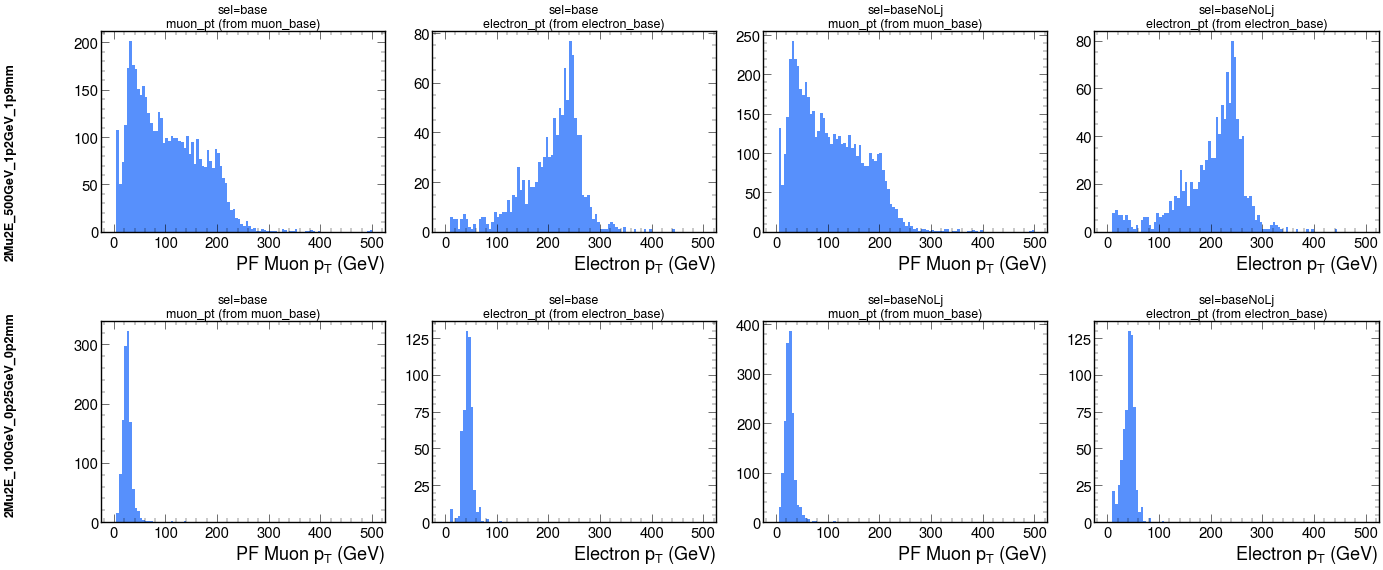

In [4]:
selections = ["base", "baseNoLj"]
hist_per_collection = {"muon_base": "muon_pt", "electron_base": "electron_pt"}
combos = [(sel, hc, hist_per_collection[hc]) for sel in selections for hc in hist_per_collection]
samples = list(samples_out.keys())

fig, axes = plt.subplots(len(samples), len(combos),
                         figsize=(7 * len(combos), 6 * len(samples)), squeeze=False)
for i, s in enumerate(samples):
    h = samples_out[s]["hists"]
    for j, (sel, hc, hname) in enumerate(combos):
        plt.sca(axes[i, j])
        utilities.plot(h[hname][sel, :], histtype="fill", skip_label=True)
        axes[i, j].set_title(f"sel={sel}\n{hname} (from {hc})", fontsize=18)
    bbox = axes[i, 0].get_position()
    fig.text(0.005, (bbox.y0 + bbox.y1) / 2, s, fontsize=18, rotation="vertical",
             va="center", ha="left", weight="bold")
plt.tight_layout(rect=(0.04, 0, 1, 1))
plt.show()

## Sharing outputs across collaborators

These outputs are world-readable under the group `lpcmetx` area, so anyone with grid access can read them — **including straight off the `/eos/uscms` mount with the load cell above**: set `PRODUCER` to the other user and `STUDY` to their study dir under `coffea_outputs/<PRODUCER>/`. The `.meta.yaml` sidecar records the selections, hist collections, input file list, and SIDM commit behind each `.coffea`, so a reader can see exactly how it was made.

```bash
# see what a collaborator has shared
ls /eos/uscms/store/group/lpcmetx/SIDM/coffea_outputs/OTHER_USER/
```

## Shut down the cluster

Workers are Condor jobs; an open cluster keeps slots reserved on the LPC pool.

In [9]:
cluster.close()
client.close()